In [248]:
from dopplerguesser.predict.fetch_tles import fetch_tles
from dopplerguesser.predict.filters import filter_visibility, filter_heo, filter_geostationary, filter_by_doppler, filter_constellations
from dopplerguesser.predict.matcher import score_candidates
from dopplerguesser.predict.observer import Observer
from dopplerguesser.predict.satellite import Satellite
from dopplerguesser.predict.propagator import propagate_earth_rotation, propagate_fg_elliptic
from dopplerguesser.misc.curve_generator import generate_doppler_curve
from matplotlib import pyplot as plt

In [249]:
from time import perf_counter
from datetime import datetime
from datetime import timezone

In [250]:
observer = Observer(lat=55.7558, lon=37.6176, alt=200)  # Moscow

In [251]:
now = datetime.now(tz=timezone.utc)
print(now)
ts = now.timestamp()
print(ts)

2026-02-03 14:00:46.298218+00:00
1770127246.298218


In [252]:
fetched_tles = fetch_tles(ts)
print(f"Fetched {len(fetched_tles)} TLEs")

Fetched 14304 TLEs


In [253]:
# with open('activesatellites.txt', 'w') as f:
#     for sat in fetched_tles:
#         f.write(f"{sat.satellite.name}\n")

In [254]:
# Filtering
print('Initial length:', len(fetched_tles))

t1 = perf_counter()
satellites = filter_constellations(fetched_tles, constellations_to_remove=['starlink', 'oneweb'])
t2 = perf_counter()
print('After constellation filter:', len(satellites))
print('Took {:.3f} seconds\n'.format(t2 - t1))

t1 = perf_counter()
satellites = filter_geostationary(satellites)
t2 = perf_counter()
print('After geostationary filter:', len(satellites))
print('Took {:.3f} seconds\n'.format(t2 - t1))

t1 = perf_counter()
satellites = filter_heo(satellites)
t2 = perf_counter()
print('After HEO filter:', len(satellites))
print('Took: {:.3f} seconds\n'.format(t2 - t1))

t1 = perf_counter()
satellites = filter_visibility(satellites, observer, ts, min_elevation=0.0)
t2 = perf_counter()
print('After visibility filter:', len(satellites))
print('Took: {:.3f} seconds\n'.format(t2 - t1))

Initial length: 14304
After constellation filter: 4099
Took 0.049 seconds

After geostationary filter: 3300
Took 0.002 seconds

After HEO filter: 3298
Took: 0.008 seconds

After visibility filter: 166
Took: 0.239 seconds



In [255]:
# Earth rotation Propagation
t1 = perf_counter()
observer.compute_track(ts)
t2 = perf_counter()
print('Earth rotation propagation took {:.3f} seconds\n'.format(t2 - t1))

Earth rotation propagation took 0.009 seconds



In [256]:
# Satellite propagation
t1 = perf_counter()
for sat in satellites:
    sat.compute_initial_state(ts)
t2 = perf_counter()
print('Satellite propagation took {:.3f} seconds\n'.format(t2 - t1))

Satellite propagation took 0.040 seconds



STARLETTE
[(np.int64(0), np.float64(2200034493.8388515)), (np.int64(1), np.float64(2200034486.1975756)), (np.int64(2), np.float64(2200034531.9558206)), (np.int64(3), np.float64(2200034387.8992333)), (np.int64(4), np.float64(2200034337.9728293)), (np.int64(5), np.float64(2200034185.4681273)), (np.int64(6), np.float64(2200034118.705759)), (np.int64(7), np.float64(2200034162.9766874)), (np.int64(8), np.float64(2200033970.0046024)), (np.int64(9), np.float64(2200033991.62615)), (np.int64(10), np.float64(2200033894.314857)), (np.int64(11), np.float64(2200033749.932256)), (np.int64(12), np.float64(2200033749.1023455)), (np.int64(13), np.float64(2200033576.911447)), (np.int64(14), np.float64(2200033571.9463444)), (np.int64(15), np.float64(2200033549.640702)), (np.int64(16), np.float64(2200033438.4312677)), (np.int64(17), np.float64(2200033277.530249)), (np.int64(18), np.float64(2200033194.297066)), (np.int64(19), np.float64(2200033076.52582)), (np.int64(20), np.float64(2200033096.99536)), (np.

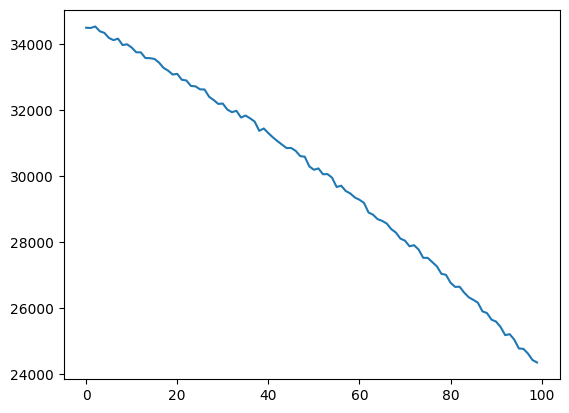

In [257]:
# Mock doppler curve generation
unknownsatellite = satellites[0]
freq = 2.2e9
print(unknownsatellite.satellite.name)
curve = generate_doppler_curve(unknownsatellite, observer, freq, ts, duration=100, step=1)
print(curve)

curveclean = [(x, y - freq) for x, y in curve]

plt.plot(*zip(*curveclean))
plt.show()

In [258]:
# Apply Doppler filter
t1 = perf_counter()
satellites = filter_by_doppler(satellites, observer, ts, freq, curve[0][1])
t2 = perf_counter()
print('After Doppler filter:', len(satellites))
print('Took: {:.3f} seconds\n'.format(t2 - t1))
print('Remaining candidates:')
for sat in satellites:
    print(sat.satellite.name)

After Doppler filter: 4
Took: 0.002 seconds

Remaining candidates:
STARLETTE
LATINSAT A
KUIPER-00066
KUIPER-00097


In [259]:
# Propagate candidates using FG elliptic model
t1 = perf_counter()
for sat in satellites:
    sat.compute_track(ts)
t2 = perf_counter()
print('FG elliptic propagation took {:.3f} seconds\n'.format(t2 - t1))

FG elliptic propagation took 0.110 seconds



In [260]:
# Score candidates
t1 = perf_counter()
scored_candidates = score_candidates(satellites, curve, freq, observer)
t2 = perf_counter()
print('\nScoring took {:.3f} seconds\n'.format(t2 - t1))
for sat, rmse in scored_candidates:
    print(f'{sat.satellite.name}: {rmse:.6f}')


Scoring took 0.010 seconds

STARLETTE: 60.029812
KUIPER-00066: 181.951169
LATINSAT A: 507.354799
KUIPER-00097: 5511.045573
